## Read GSOD daily data from DuckDB

This section reads the local GSOD Philippines database using DuckDB. The database has already been converted to metric units, so precipitation is read directly from `PRCP_mm` and is not converted from inches.

The goal is to prepare selected NCR-adjacent GSOD stations in the same daily format used by the Science Garden workflow:

- `STATION_ID`
- `STATION_NAME`
- `LATITUDE`
- `LONGITUDE`
- `DATE`
- `YEAR`
- `MONTH`
- `DAY`
- `RAINFALL`

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import linregress, norm, t

In [2]:
GSOD_EXPORT_DIR = Path("/home/jupyter-bbr/notebooks/gsod/exports")

GSOD_STATION_INVENTORY_PATH = GSOD_EXPORT_DIR / "gsod_station_inventory_1980_2024.csv"
GSOD_DAILY_PATH = GSOD_EXPORT_DIR / "gsod_daily_metric_ncr_adjacent_1980_2024.csv"

OUTPUT_DIR = Path("output")
GSOD_OUTPUT_DIR = OUTPUT_DIR / "gsod_sanity_check"
GSOD_TABLE_DIR = GSOD_OUTPUT_DIR / "tables"
GSOD_FIGURE_DIR = GSOD_OUTPUT_DIR / "figures"

for path in [GSOD_OUTPUT_DIR, GSOD_TABLE_DIR, GSOD_FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

START_YEAR = 1980
END_YEAR = 2024

WET_DAY_THRESHOLD = 1.0
MIN_VALID_FRACTION = 0.90

DRY_MONTHS = [11, 12, 1, 2, 3, 4]
WET_MONTHS = [5, 6, 7, 8, 9, 10]

DRY_SEASON_LABEL = "Nov-Apr"
WET_SEASON_LABEL = "May-Oct"
SEASON_ORDER = [DRY_SEASON_LABEL, WET_SEASON_LABEL]

In [3]:
station_inventory = pd.read_csv(
    GSOD_STATION_INVENTORY_PATH,
    dtype={"station_id": str}
)

gsod_daily = pd.read_csv(
    GSOD_DAILY_PATH,
    parse_dates=["DATE"],
    dtype={"STATION_ID": str}
)

gsod_daily["RAINFALL"] = pd.to_numeric(gsod_daily["RAINFALL"], errors="coerce")

display(station_inventory.head())
display(gsod_daily.head())

print(gsod_daily.shape)
print(gsod_daily.columns.tolist())

,station_id,station_name,latitude,longitude,first_date,last_date,n_rows,valid_rainfall_days,mean_rainfall_mm,max_rainfall_mm,first_year,last_year,record_years,inside_ncr_adjacent_bbox
0,98430099999,SCIENCE GARDEN,14.650,121.050,1980-01-01,2024-12-31,15402,15117,5.948224,490.982,1980,2024,45,True
1,98429099999,NINOY AQUINO INTL,14.509,121.020,1980-01-01,2024-12-31,16406,14713,2.751411,400.050,1980,2024,45,True
2,98427099999,TAYABAS,14.017,121.600,1980-01-01,2024-12-31,14843,14606,7.523189,500.126,1980,2024,45,True
3,98432099999,AMBULONG,14.083,121.050,1980-01-01,2024-12-31,12818,12650,4.727372,436.372,1980,2024,45,True
4,98425099999,MANILA,14.583,120.983,1981-05-18,2023-11-30,14067,13818,5.339423,427.990,1981,2023,43,True


,STATION_ID,STATION_NAME,LATITUDE,LONGITUDE,DATE,YEAR,MONTH,DAY,RAINFALL
0,69176499999,CLARK INTL,15.183,120.567001,1985-03-12,1985,3,12,0.0
1,69176499999,CLARK INTL,15.183,120.567001,1986-04-18,1986,4,18,NaN
2,69176499999,CLARK INTL,15.183,120.567001,1986-04-19,1986,4,19,NaN
3,69176499999,CLARK INTL,15.183,120.567001,1986-04-22,1986,4,22,NaN
4,69176499999,CLARK INTL,15.183,120.567001,1986-04-23,1986,4,23,NaN


(97347, 9)
['STATION_ID', 'STATION_NAME', 'LATITUDE', 'LONGITUDE', 'DATE', 'YEAR', 'MONTH', 'DAY', 'RAINFALL']


In [4]:
SELECTED_STATION_IDS = [
    "98429099999",
    "98425099999",
    "98430099999",
]

In [5]:
SELECTED_STATION_IDS = [str(x).strip() for x in SELECTED_STATION_IDS]

available_ids = set(gsod_daily["STATION_ID"].astype(str).unique())
missing_ids = [x for x in SELECTED_STATION_IDS if x not in available_ids]

if len(missing_ids) > 0:
    print("Missing selected station IDs:")
    print(missing_ids)

gsod_selected = gsod_daily[
    gsod_daily["STATION_ID"].astype(str).isin(SELECTED_STATION_IDS)
].copy()

gsod_selected = gsod_selected.sort_values(["STATION_ID", "DATE"]).reset_index(drop=True)

display(gsod_selected.head())
display(gsod_selected["STATION_ID"].value_counts())

print("Selected stations:", gsod_selected["STATION_ID"].nunique())

,STATION_ID,STATION_NAME,LATITUDE,LONGITUDE,DATE,YEAR,MONTH,DAY,RAINFALL
0,98425099999,MANILA,14.583,120.983002,1981-05-18,1981,5,18,0.000000
1,98425099999,MANILA,14.583,120.983002,1981-06-12,1981,6,12,0.000000
2,98425099999,MANILA,14.583,120.983002,1981-06-13,1981,6,13,39.877998
3,98425099999,MANILA,14.583,120.983002,1981-06-17,1981,6,17,2.032000
4,98425099999,MANILA,14.583,120.983002,1981-06-19,1981,6,19,8.890000


STATION_ID
98429099999    16406
98430099999    15402
98425099999    14067
Name: count, dtype: int64

Selected stations: 3


In [6]:
def reindex_station_daily(group):
    station_id = group["STATION_ID"].iloc[0]
    
    full_dates = pd.DataFrame({
        "DATE": pd.date_range(
            start=f"{START_YEAR}-01-01",
            end=f"{END_YEAR}-12-31",
            freq="D",
        )
    })
    
    out = full_dates.merge(group, on="DATE", how="left")
    
    out["STATION_ID"] = station_id
    out["YEAR"] = out["DATE"].dt.year
    out["MONTH"] = out["DATE"].dt.month
    out["DAY"] = out["DATE"].dt.day
    
    for col in ["STATION_NAME", "LATITUDE", "LONGITUDE"]:
        if col in out.columns:
            out[col] = out[col].ffill().bfill()
    
    return out


gsod_selected_daily = (
    gsod_selected
    .groupby("STATION_ID", group_keys=False)
    .apply(reindex_station_daily)
    .reset_index(drop=True)
)

display(gsod_selected_daily.head())
display(gsod_selected_daily.tail())

print(gsod_selected_daily.shape)

/tmp/ipykernel_1423522/2190914586.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(reindex_station_daily)


,DATE,STATION_ID,STATION_NAME,LATITUDE,LONGITUDE,YEAR,MONTH,DAY,RAINFALL
0,1980-01-01,98425099999,MANILA,14.583,120.983002,1980,1,1,NaN
1,1980-01-02,98425099999,MANILA,14.583,120.983002,1980,1,2,NaN
2,1980-01-03,98425099999,MANILA,14.583,120.983002,1980,1,3,NaN
3,1980-01-04,98425099999,MANILA,14.583,120.983002,1980,1,4,NaN
4,1980-01-05,98425099999,MANILA,14.583,120.983002,1980,1,5,NaN


,DATE,STATION_ID,STATION_NAME,LATITUDE,LONGITUDE,YEAR,MONTH,DAY,RAINFALL
49306,2024-12-27,98430099999,SCIENCE GARDEN,14.65,121.050003,2024,12,27,0.000
49307,2024-12-28,98430099999,SCIENCE GARDEN,14.65,121.050003,2024,12,28,6.858
49308,2024-12-29,98430099999,SCIENCE GARDEN,14.65,121.050003,2024,12,29,10.922
49309,2024-12-30,98430099999,SCIENCE GARDEN,14.65,121.050003,2024,12,30,9.652
49310,2024-12-31,98430099999,SCIENCE GARDEN,14.65,121.050003,2024,12,31,3.048


(49311, 9)


In [7]:
gsod_selected_daily.STATION_ID.unique()

array(['98425099999', '98429099999', '98430099999'], dtype=object)

In [8]:
IBTRACS_PATH = Path("data/ibtracs.WP.list.v04r01.csv")

TC_RADII_KM = [250, 500, 1000]
PRIMARY_TC_RADIUS_KM = 1000
TC_FILTER_COL = f"tc_{PRIMARY_TC_RADIUS_KM}km"

if not IBTRACS_PATH.exists():
    raise FileNotFoundError(f"IBTrACS file not found: {IBTRACS_PATH}")

In [9]:
def normalize_lon_180(lon):
    """
    Normalize longitude to the -180 to 180 range.
    """
    return ((np.asarray(lon, dtype=float) + 180) % 360) - 180


def haversine_km(lat1, lon1, lat2, lon2):
    """
    Great-circle distance between points in kilometers.
    
    lat1/lon1 may be scalar or array-like.
    lat2/lon2 may be scalar or array-like.
    """
    earth_radius_km = 6371.0
    
    lat1 = np.radians(np.asarray(lat1, dtype=float))
    lon1 = np.radians(normalize_lon_180(lon1))
    lat2 = np.radians(np.asarray(lat2, dtype=float))
    lon2 = np.radians(normalize_lon_180(lon2))
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )
    
    c = 2 * np.arcsin(np.sqrt(a))
    
    return earth_radius_km * c

In [10]:
ibtracs = pd.read_csv(
    IBTRACS_PATH,
    skiprows=[1],
    usecols=["SID", "ISO_TIME", "LAT", "LON"],
    low_memory=False,
)

ibtracs["ISO_TIME"] = pd.to_datetime(
    ibtracs["ISO_TIME"],
    errors="coerce",
    utc=True,
)

ibtracs["LAT"] = pd.to_numeric(ibtracs["LAT"], errors="coerce")
ibtracs["LON"] = pd.to_numeric(ibtracs["LON"], errors="coerce")

ibtracs = ibtracs.dropna(subset=["SID", "ISO_TIME", "LAT", "LON"]).copy()

ibtracs["DATE"] = ibtracs["ISO_TIME"].dt.floor("D").dt.tz_localize(None)
ibtracs["YEAR"] = ibtracs["DATE"].dt.year

# Add a small buffer because dry seasons can cross calendar years.
ibtracs = ibtracs[
    (ibtracs["YEAR"] >= START_YEAR - 1)
    & (ibtracs["YEAR"] <= END_YEAR)
].copy()

ibtracs = ibtracs.sort_values(["SID", "ISO_TIME"]).reset_index(drop=True)

display(ibtracs.head())
print(ibtracs.shape)

,SID,ISO_TIME,LAT,LON,DATE,YEAR
0,1978361N02180,1979-01-01 00:00:00+00:00,2.7,171.0,1979-01-01,1979
1,1978361N02180,1979-01-01 03:00:00+00:00,3.0,170.6,1979-01-01,1979
2,1978361N02180,1979-01-01 06:00:00+00:00,3.3,170.2,1979-01-01,1979
3,1978361N02180,1979-01-01 09:00:00+00:00,3.6,169.9,1979-01-01,1979
4,1978361N02180,1979-01-01 12:00:00+00:00,4.0,169.7,1979-01-01,1979


(107740, 6)


In [11]:
selected_station_metadata = (
    gsod_selected_daily
    .groupby("STATION_ID")
    .agg(
        STATION_NAME=("STATION_NAME", "first"),
        LATITUDE=("LATITUDE", "median"),
        LONGITUDE=("LONGITUDE", "median"),
    )
    .reset_index()
)

display(selected_station_metadata)

,STATION_ID,STATION_NAME,LATITUDE,LONGITUDE
0,98425099999,MANILA,14.583,120.983002
1,98429099999,NINOY AQUINO INTL,14.509,121.019997
2,98430099999,SCIENCE GARDEN,14.650,121.050003


In [12]:
def build_station_tc_daily_summary(station_row, ibtracs_df, tc_radii_km):
    """
    Calculate daily TC proximity summary for one station.

    Each storm is first reduced to its nearest position to the station per day.
    Then each station-day is summarized across storms.
    """
    station_id = str(station_row["STATION_ID"])
    station_lat = float(station_row["LATITUDE"])
    station_lon = float(station_row["LONGITUDE"])
    
    tc = ibtracs_df.copy()
    
    tc["distance_km"] = haversine_km(
        station_lat,
        station_lon,
        tc["LAT"].to_numpy(),
        tc["LON"].to_numpy(),
    )
    
    # For each storm-day, keep the nearest 6-hourly or subdaily position.
    storm_day_nearest = (
        tc.sort_values("distance_km")
        .groupby(["DATE", "SID"], as_index=False)
        .first()
    )
    
    rows = []
    
    for date, g in storm_day_nearest.groupby("DATE"):
        row = {
            "STATION_ID": station_id,
            "DATE": date,
            "nearest_tc_distance_km": g["distance_km"].min(),
            "nearest_tc_sid": g.loc[g["distance_km"].idxmin(), "SID"],
        }
        
        for radius in tc_radii_km:
            within = g[g["distance_km"] <= radius].copy()
            
            row[f"tc_{radius}km"] = len(within) > 0
            row[f"tc_count_{radius}km"] = within["SID"].nunique()
            row[f"tc_sids_{radius}km"] = (
                ",".join(sorted(within["SID"].astype(str).unique()))
                if len(within) > 0
                else ""
            )
        
        rows.append(row)
    
    return pd.DataFrame(rows)


tc_summary_list = []

for _, station_row in selected_station_metadata.iterrows():
    print(f"Processing TC proximity for {station_row['STATION_ID']} – {station_row['STATION_NAME']}")
    
    station_tc_summary = build_station_tc_daily_summary(
        station_row=station_row,
        ibtracs_df=ibtracs,
        tc_radii_km=TC_RADII_KM,
    )
    
    tc_summary_list.append(station_tc_summary)

gsod_tc_daily_summary = pd.concat(tc_summary_list, ignore_index=True)

display(gsod_tc_daily_summary.head())
print(gsod_tc_daily_summary.shape)

Processing TC proximity for 98425099999 – MANILA
Processing TC proximity for 98429099999 – NINOY AQUINO INTL
Processing TC proximity for 98430099999 – SCIENCE GARDEN


,STATION_ID,DATE,nearest_tc_distance_km,nearest_tc_sid,tc_250km,tc_count_250km,tc_sids_250km,tc_500km,tc_count_500km,tc_sids_500km,tc_1000km,tc_count_1000km,tc_sids_1000km
0,98425099999,1979-01-01,5359.864472,1978361N02180,False,0,,False,0,,False,0,
1,98425099999,1979-01-02,5170.523231,1978361N02180,False,0,,False,0,,False,0,
2,98425099999,1979-01-03,5155.104365,1978361N02180,False,0,,False,0,,False,0,
3,98425099999,1979-01-04,4866.627556,1978361N02180,False,0,,False,0,,False,0,
4,98425099999,1979-01-05,4483.178066,1978361N02180,False,0,,False,0,,False,0,


(25476, 13)


In [13]:
gsod_selected_daily = gsod_selected_daily.merge(
    gsod_tc_daily_summary,
    on=["STATION_ID", "DATE"],
    how="left",
)

# Fill no-TC days.
for radius in TC_RADII_KM:
    flag_col = f"tc_{radius}km"
    count_col = f"tc_count_{radius}km"
    sids_col = f"tc_sids_{radius}km"
    
    gsod_selected_daily[flag_col] = (
        gsod_selected_daily[flag_col]
        .fillna(False)
        .astype(bool)
    )
    
    gsod_selected_daily[count_col] = (
        gsod_selected_daily[count_col]
        .fillna(0)
        .astype(int)
    )
    
    gsod_selected_daily[sids_col] = (
        gsod_selected_daily[sids_col]
        .fillna("")
    )

gsod_selected_daily["nearest_tc_distance_km"] = pd.to_numeric(
    gsod_selected_daily["nearest_tc_distance_km"],
    errors="coerce",
)

display(gsod_selected_daily.head())

/tmp/ipykernel_1423522/1775502807.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/tmp/ipykernel_1423522/1775502807.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/tmp/ipykernel_1423522/1775502807.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


,DATE,STATION_ID,STATION_NAME,LATITUDE,LONGITUDE,YEAR,MONTH,DAY,RAINFALL,nearest_tc_distance_km,nearest_tc_sid,tc_250km,tc_count_250km,tc_sids_250km,tc_500km,tc_count_500km,tc_sids_500km,tc_1000km,tc_count_1000km,tc_sids_1000km
0,1980-01-01,98425099999,MANILA,14.583,120.983002,1980,1,1,NaN,NaN,NaN,False,0,,False,0,,False,0,
1,1980-01-02,98425099999,MANILA,14.583,120.983002,1980,1,2,NaN,NaN,NaN,False,0,,False,0,,False,0,
2,1980-01-03,98425099999,MANILA,14.583,120.983002,1980,1,3,NaN,NaN,NaN,False,0,,False,0,,False,0,
3,1980-01-04,98425099999,MANILA,14.583,120.983002,1980,1,4,NaN,NaN,NaN,False,0,,False,0,,False,0,
4,1980-01-05,98425099999,MANILA,14.583,120.983002,1980,1,5,NaN,NaN,NaN,False,0,,False,0,,False,0,


In [14]:
gsod_selected_daily["RAINFALL_all"] = gsod_selected_daily["RAINFALL"]

gsod_selected_daily["RAINFALL_non_tc_1000km"] = gsod_selected_daily["RAINFALL"].where(
    ~gsod_selected_daily[TC_FILTER_COL],
    np.nan,
)

display(
    gsod_selected_daily[
        [
            "STATION_ID",
            "DATE",
            "RAINFALL",
            TC_FILTER_COL,
            "RAINFALL_all",
            "RAINFALL_non_tc_1000km",
        ]
    ].head()
)

,STATION_ID,DATE,RAINFALL,tc_1000km,RAINFALL_all,RAINFALL_non_tc_1000km
0,98425099999,1980-01-01,NaN,False,NaN,NaN
1,98425099999,1980-01-02,NaN,False,NaN,NaN
2,98425099999,1980-01-03,NaN,False,NaN,NaN
3,98425099999,1980-01-04,NaN,False,NaN,NaN
4,98425099999,1980-01-05,NaN,False,NaN,NaN


In [15]:
def expected_days_in_year(year):
    return pd.Timestamp(year=int(year), month=12, day=31).dayofyear


def expected_days_in_month(year, month):
    return pd.Timestamp(year=int(year), month=int(month), day=1).days_in_month


def expected_days_in_season(season_year, season):
    season_year = int(season_year)
    
    if season == DRY_SEASON_LABEL:
        dates = pd.date_range(
            start=f"{season_year - 1}-11-01",
            end=f"{season_year}-04-30",
            freq="D",
        )
    elif season == WET_SEASON_LABEL:
        dates = pd.date_range(
            start=f"{season_year}-05-01",
            end=f"{season_year}-10-31",
            freq="D",
        )
    else:
        return np.nan
    
    return len(dates)

In [16]:
gsod_annual_completeness = (
    gsod_selected_daily
    .groupby(["STATION_ID", "YEAR"])
    .agg(
        station_name=("STATION_NAME", "first"),
        latitude=("LATITUDE", "first"),
        longitude=("LONGITUDE", "first"),
        valid_days=("RAINFALL", "count"),
        wet_days=("RAINFALL", lambda x: (x >= WET_DAY_THRESHOLD).sum()),
        total_rainfall_mm=("RAINFALL", "sum"),
    )
    .reset_index()
)

gsod_annual_completeness["expected_days"] = gsod_annual_completeness["YEAR"].apply(
    expected_days_in_year
)

gsod_annual_completeness["valid_fraction"] = (
    gsod_annual_completeness["valid_days"]
    / gsod_annual_completeness["expected_days"]
)

gsod_annual_completeness["is_valid_year"] = (
    gsod_annual_completeness["valid_fraction"] >= MIN_VALID_FRACTION
)

display(gsod_annual_completeness.head())

display(
    gsod_annual_completeness
    .groupby(["STATION_ID", "station_name"])
    .agg(
        first_year=("YEAR", "min"),
        last_year=("YEAR", "max"),
        valid_years=("is_valid_year", "sum"),
        mean_valid_fraction=("valid_fraction", "mean"),
        min_valid_fraction=("valid_fraction", "min"),
    )
    .reset_index()
    .sort_values("valid_years", ascending=False)
)

,STATION_ID,YEAR,station_name,latitude,longitude,valid_days,wet_days,total_rainfall_mm,expected_days,valid_fraction,is_valid_year
0,98425099999,1980,MANILA,14.583,120.983002,0,0,0.000000,366,0.000000,False
1,98425099999,1981,MANILA,14.583,120.983002,154,43,518.159998,365,0.421918,False
2,98425099999,1982,MANILA,14.583,120.983002,327,33,780.542008,365,0.895890,False
3,98425099999,1983,MANILA,14.583,120.983002,274,19,119.888001,365,0.750685,False
4,98425099999,1984,MANILA,14.583,120.983002,313,42,1367.027980,366,0.855191,False


,STATION_ID,station_name,first_year,last_year,valid_years,mean_valid_fraction,min_valid_fraction
1,98429099999,NINOY AQUINO INTL,1980,2024,34,0.895111,0.505464
2,98430099999,SCIENCE GARDEN,1980,2024,32,0.919690,0.589041
0,98425099999,MANILA,1980,2024,29,0.840769,0.000000


In [17]:
def assign_season(month):
    if month in DRY_MONTHS:
        return DRY_SEASON_LABEL
    elif month in WET_MONTHS:
        return WET_SEASON_LABEL
    else:
        return np.nan


def assign_season_year(row):
    month = row["MONTH"]
    year = row["YEAR"]
    season = row["SEASON"]
    
    if season == DRY_SEASON_LABEL and month in [11, 12]:
        return year + 1
    
    return year


gsod_selected_daily["SEASON"] = gsod_selected_daily["MONTH"].apply(assign_season)
gsod_selected_daily["SEASON_YEAR"] = gsod_selected_daily.apply(assign_season_year, axis=1)

gsod_selected_daily["SEASON"] = pd.Categorical(
    gsod_selected_daily["SEASON"],
    categories=SEASON_ORDER,
    ordered=True,
)

display(gsod_selected_daily[["DATE", "YEAR", "MONTH", "SEASON", "SEASON_YEAR"]].head())
display(gsod_selected_daily[["DATE", "YEAR", "MONTH", "SEASON", "SEASON_YEAR"]].tail())

,DATE,YEAR,MONTH,SEASON,SEASON_YEAR
0,1980-01-01,1980,1,Nov-Apr,1980
1,1980-01-02,1980,1,Nov-Apr,1980
2,1980-01-03,1980,1,Nov-Apr,1980
3,1980-01-04,1980,1,Nov-Apr,1980
4,1980-01-05,1980,1,Nov-Apr,1980


,DATE,YEAR,MONTH,SEASON,SEASON_YEAR
49306,2024-12-27,2024,12,Nov-Apr,2025
49307,2024-12-28,2024,12,Nov-Apr,2025
49308,2024-12-29,2024,12,Nov-Apr,2025
49309,2024-12-30,2024,12,Nov-Apr,2025
49310,2024-12-31,2024,12,Nov-Apr,2025


In [18]:
def get_run_lengths(flag_series):
    arr = pd.Series(flag_series).fillna(False).astype(bool).to_numpy()
    
    run_lengths = []
    current_length = 0
    
    for value in arr:
        if value:
            current_length += 1
        else:
            if current_length > 0:
                run_lengths.append(current_length)
            current_length = 0
    
    if current_length > 0:
        run_lengths.append(current_length)
    
    return run_lengths


def rx5day_calendar(rr):
    rr = pd.Series(rr).astype(float)
    return rr.rolling(window=5, min_periods=5).sum().max()


def calculate_rainfall_indices_for_period(rr, wet_threshold=1.0):
    rr = pd.Series(rr).astype(float)
    eligible_days = rr.notna().sum()
    
    if eligible_days == 0:
        return {
            "eligible_days": 0,
            "PRCPTOT": np.nan,
            "WD": np.nan,
            "WD_RATE": np.nan,
            "SDII": np.nan,
            "R20mm": np.nan,
            "R50mm": np.nan,
            "R100mm": np.nan,
            "RX1day": np.nan,
            "RX5day": np.nan,
            "DD": np.nan,
            "DD_RATE": np.nan,
            "CDD": np.nan,
            "CWD": np.nan,
            "MEAN_DRY_SPELL_LENGTH": np.nan,
            "TOTAL_DRY_SPELL_DAYS_GE7": np.nan,
        }
    
    wet = (rr >= wet_threshold) & rr.notna()
    dry = (rr < wet_threshold) & rr.notna()
    
    wet_lengths = get_run_lengths(wet)
    dry_lengths = get_run_lengths(dry)
    dry_lengths_ge7 = [x for x in dry_lengths if x >= 7]
    
    wd = int(wet.sum())
    dd = int(dry.sum())
    
    prcptot = rr.where(wet).sum()
    sdii = prcptot / wd if wd > 0 else np.nan
    
    return {
        "eligible_days": int(eligible_days),
        "PRCPTOT": prcptot,
        "WD": wd,
        "WD_RATE": wd / eligible_days,
        "SDII": sdii,
        "R20mm": int((rr >= 20).sum()),
        "R50mm": int((rr >= 50).sum()),
        "R100mm": int((rr >= 100).sum()),
        "RX1day": rr.max(),
        "RX5day": rx5day_calendar(rr),
        "DD": dd,
        "DD_RATE": dd / eligible_days,
        "CDD": max(dry_lengths) if len(dry_lengths) > 0 else 0,
        "CWD": max(wet_lengths) if len(wet_lengths) > 0 else 0,
        "MEAN_DRY_SPELL_LENGTH": np.mean(dry_lengths) if len(dry_lengths) > 0 else 0,
        "TOTAL_DRY_SPELL_DAYS_GE7": sum(dry_lengths_ge7) if len(dry_lengths_ge7) > 0 else 0,
    }

In [19]:
def calculate_gsod_annual_indices(data, rr_col, subset_name):
    rows = []
    
    group_cols = ["STATION_ID", "YEAR"]
    
    for (station_id, year), g in data.groupby(group_cols):
        g = g.sort_values("DATE")
        
        rr = g[rr_col]
        
        # Completeness is based on original rainfall availability,
        # not on TC-masked rainfall.
        rr_base = g["RAINFALL"]
        
        expected_days = expected_days_in_year(year)
        valid_days = rr_base.notna().sum()
        valid_fraction = valid_days / expected_days
        
        base = {
            "STATION_ID": station_id,
            "STATION_NAME": g["STATION_NAME"].dropna().iloc[0] if g["STATION_NAME"].notna().any() else np.nan,
            "LATITUDE": g["LATITUDE"].dropna().iloc[0] if g["LATITUDE"].notna().any() else np.nan,
            "LONGITUDE": g["LONGITUDE"].dropna().iloc[0] if g["LONGITUDE"].notna().any() else np.nan,
            "period_type": "Annual",
            "period": "Annual",
            "subset": subset_name,
            "YEAR": int(year),
            "expected_days": expected_days,
            "valid_days": valid_days,
            "valid_fraction": valid_fraction,
            "is_valid": valid_fraction >= MIN_VALID_FRACTION,
        }
        
        if valid_fraction >= MIN_VALID_FRACTION:
            indices = calculate_rainfall_indices_for_period(
                rr,
                wet_threshold=WET_DAY_THRESHOLD,
            )
        else:
            indices = calculate_rainfall_indices_for_period(
                pd.Series(dtype=float),
                wet_threshold=WET_DAY_THRESHOLD,
            )
        
        rows.append({**base, **indices})
    
    return pd.DataFrame(rows)

In [20]:
def calculate_gsod_seasonal_indices(data, rr_col, subset_name):
    rows = []
    
    group_cols = ["STATION_ID", "SEASON_YEAR", "SEASON"]
    
    for (station_id, season_year, season), g in data.groupby(group_cols, observed=True):
        g = g.sort_values("DATE")
        season = str(season)
        
        rr = g[rr_col]
        
        # Completeness is based on original rainfall availability,
        # not on TC-masked rainfall.
        rr_base = g["RAINFALL"]
        
        expected_days = expected_days_in_season(season_year, season)
        valid_days = rr_base.notna().sum()
        valid_fraction = valid_days / expected_days
        
        base = {
            "STATION_ID": station_id,
            "STATION_NAME": g["STATION_NAME"].dropna().iloc[0] if g["STATION_NAME"].notna().any() else np.nan,
            "LATITUDE": g["LATITUDE"].dropna().iloc[0] if g["LATITUDE"].notna().any() else np.nan,
            "LONGITUDE": g["LONGITUDE"].dropna().iloc[0] if g["LONGITUDE"].notna().any() else np.nan,
            "period_type": "Seasonal",
            "period": season,
            "subset": subset_name,
            "YEAR": int(season_year),
            "SEASON_YEAR": int(season_year),
            "SEASON": season,
            "expected_days": expected_days,
            "valid_days": valid_days,
            "valid_fraction": valid_fraction,
            "is_valid": valid_fraction >= MIN_VALID_FRACTION,
        }
        
        if valid_fraction >= MIN_VALID_FRACTION:
            indices = calculate_rainfall_indices_for_period(
                rr,
                wet_threshold=WET_DAY_THRESHOLD,
            )
        else:
            indices = calculate_rainfall_indices_for_period(
                pd.Series(dtype=float),
                wet_threshold=WET_DAY_THRESHOLD,
            )
        
        rows.append({**base, **indices})
    
    out = pd.DataFrame(rows)
    
    if not out.empty:
        out["SEASON"] = pd.Categorical(
            out["SEASON"],
            categories=SEASON_ORDER,
            ordered=True,
        )
    
    return out

In [21]:
gsod_annual_indices_all = calculate_gsod_annual_indices(
    data=gsod_selected_daily,
    rr_col="RAINFALL_all",
    subset_name="all_days",
)

gsod_annual_indices_non_tc = calculate_gsod_annual_indices(
    data=gsod_selected_daily,
    rr_col="RAINFALL_non_tc_1000km",
    subset_name="non_tc_1000km",
)

gsod_annual_indices = pd.concat(
    [gsod_annual_indices_all, gsod_annual_indices_non_tc],
    ignore_index=True,
)


gsod_seasonal_indices_all = calculate_gsod_seasonal_indices(
    data=gsod_selected_daily,
    rr_col="RAINFALL_all",
    subset_name="all_days",
)

gsod_seasonal_indices_non_tc = calculate_gsod_seasonal_indices(
    data=gsod_selected_daily,
    rr_col="RAINFALL_non_tc_1000km",
    subset_name="non_tc_1000km",
)

gsod_seasonal_indices = pd.concat(
    [gsod_seasonal_indices_all, gsod_seasonal_indices_non_tc],
    ignore_index=True,
)

gsod_all_period_indices = pd.concat(
    [gsod_annual_indices, gsod_seasonal_indices],
    ignore_index=True,
    sort=False,
)

display(gsod_all_period_indices.head())

,STATION_ID,STATION_NAME,LATITUDE,LONGITUDE,period_type,period,subset,YEAR,expected_days,valid_days,...,RX1day,RX5day,DD,DD_RATE,CDD,CWD,MEAN_DRY_SPELL_LENGTH,TOTAL_DRY_SPELL_DAYS_GE7,SEASON_YEAR,SEASON
0,98425099999,MANILA,14.583,120.983002,Annual,Annual,all_days,1980,366,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,98425099999,MANILA,14.583,120.983002,Annual,Annual,all_days,1981,365,154,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,98425099999,MANILA,14.583,120.983002,Annual,Annual,all_days,1982,365,327,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,98425099999,MANILA,14.583,120.983002,Annual,Annual,all_days,1983,365,274,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,98425099999,MANILA,14.583,120.983002,Annual,Annual,all_days,1984,366,313,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
# -----------------------------
# Indices to include in trend analysis
# -----------------------------

TREND_INDICES = [
    "PRCPTOT",
    "WD",
    "WD_RATE",
    "SDII",
    "R20mm",
    "R50mm",
    "R100mm",
    "RX1day",
    "RX5day",
    "DD",
    "DD_RATE",
    "CDD",
    "CWD",
    "MEAN_DRY_SPELL_LENGTH",
    "TOTAL_DRY_SPELL_DAYS_GE7",
]

In [23]:
# -----------------------------
# Trend helper functions
# -----------------------------

from scipy.stats import linregress, norm, t


def mann_kendall_test(y, alpha=0.05):
    """
    Original Mann-Kendall trend test with tie correction.

    Input:
        y: annual or seasonal index series

    Output:
        MK statistic, variance, z-score, p-value, Kendall tau, and trend label.
    """
    y = pd.Series(y).dropna().to_numpy()
    n = len(y)
    
    if n < 3:
        return {
            "mk_s": np.nan,
            "mk_var_s": np.nan,
            "mk_z": np.nan,
            "mk_p_value": np.nan,
            "mk_tau": np.nan,
            "mk_trend": "no_test",
        }
    
    s = 0
    
    for k in range(n - 1):
        s += np.sum(np.sign(y[(k + 1):] - y[k]))
    
    unique_y, counts = np.unique(y, return_counts=True)
    tie_term = np.sum(counts * (counts - 1) * (2 * counts + 5))
    
    var_s = (
        n * (n - 1) * (2 * n + 5) - tie_term
    ) / 18
    
    if var_s == 0:
        z = 0
    elif s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s < 0:
        z = (s + 1) / np.sqrt(var_s)
    else:
        z = 0
    
    p_value = 2 * (1 - norm.cdf(abs(z)))
    tau = s / (0.5 * n * (n - 1))
    
    if p_value < alpha and z > 0:
        trend = "increasing"
    elif p_value < alpha and z < 0:
        trend = "decreasing"
    else:
        trend = "not_significant"
    
    return {
        "mk_s": s,
        "mk_var_s": var_s,
        "mk_z": z,
        "mk_p_value": p_value,
        "mk_tau": tau,
        "mk_trend": trend,
    }


def theil_sen_slope(x, y):
    """
    Median pairwise Theil-Sen slope.

    Slope is calculated per year, then converted to per decade.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    
    if len(x) < 2:
        return {
            "theil_sen_slope_per_year": np.nan,
            "theil_sen_slope_per_decade": np.nan,
        }
    
    slopes = []
    
    for i in range(len(x) - 1):
        dx = x[(i + 1):] - x[i]
        dy = y[(i + 1):] - y[i]
        
        valid = dx != 0
        
        if np.any(valid):
            slopes.extend((dy[valid] / dx[valid]).tolist())
    
    if len(slopes) == 0:
        slope_per_year = np.nan
    else:
        slope_per_year = np.median(slopes)
    
    return {
        "theil_sen_slope_per_year": slope_per_year,
        "theil_sen_slope_per_decade": (
            slope_per_year * 10 if pd.notna(slope_per_year) else np.nan
        ),
    }


def ols_trend(x, y, alpha=0.05):
    """
    Ordinary least-squares linear trend.

    The regression is fit against YEAR, so the raw slope is per year.
    The slope and confidence intervals are also reported per decade.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    
    if len(x) < 3:
        return {
            "n_valid_periods": len(x),
            "year_start": np.nan,
            "year_end": np.nan,
            "ols_slope_per_year": np.nan,
            "ols_slope_per_decade": np.nan,
            "ols_ci_lower_per_decade": np.nan,
            "ols_ci_upper_per_decade": np.nan,
            "ols_intercept": np.nan,
            "ols_r_value": np.nan,
            "ols_p_value": np.nan,
            "ols_stderr_per_year": np.nan,
            "ols_trend": "no_test",
        }
    
    result = linregress(x, y)
    
    dof = len(x) - 2
    tcrit = t.ppf(1 - alpha / 2, dof)
    
    slope_per_year = result.slope
    slope_per_decade = slope_per_year * 10
    
    ci_lower_per_decade = (slope_per_year - tcrit * result.stderr) * 10
    ci_upper_per_decade = (slope_per_year + tcrit * result.stderr) * 10
    
    if result.pvalue < alpha and slope_per_year > 0:
        trend = "increasing"
    elif result.pvalue < alpha and slope_per_year < 0:
        trend = "decreasing"
    else:
        trend = "not_significant"
    
    return {
        "n_valid_periods": len(x),
        "year_start": int(np.min(x)),
        "year_end": int(np.max(x)),
        "ols_slope_per_year": slope_per_year,
        "ols_slope_per_decade": slope_per_decade,
        "ols_ci_lower_per_decade": ci_lower_per_decade,
        "ols_ci_upper_per_decade": ci_upper_per_decade,
        "ols_intercept": result.intercept,
        "ols_r_value": result.rvalue,
        "ols_p_value": result.pvalue,
        "ols_stderr_per_year": result.stderr,
        "ols_trend": trend,
    }


def calculate_combined_trend(data, index_name, x_col="YEAR", alpha=0.05):
    """
    Calculate OLS, Mann-Kendall, and Theil-Sen trends for one index.

    Input data should contain:
        x_col, usually YEAR
        index_name, e.g. PRCPTOT, WD_RATE, CDD
    """
    g = data[[x_col, index_name]].dropna().copy()
    
    if g.empty:
        ols = ols_trend([], [], alpha=alpha)
        mk = mann_kendall_test([], alpha=alpha)
        ts = theil_sen_slope([], [])
        return {**ols, **mk, **ts}
    
    ols = ols_trend(
        x=g[x_col],
        y=g[index_name],
        alpha=alpha,
    )
    
    mk = mann_kendall_test(
        y=g[index_name],
        alpha=alpha,
    )
    
    ts = theil_sen_slope(
        x=g[x_col],
        y=g[index_name],
    )
    
    return {**ols, **mk, **ts}

In [24]:
trend_rows = []

group_cols = ["STATION_ID", "STATION_NAME", "period_type", "period", "subset"]

for (station_id, station_name, period_type, period, subset), g in gsod_all_period_indices.groupby(
    group_cols,
    observed=True,
):
    g = g.sort_values("YEAR").copy()
    
    for index_name in TREND_INDICES:
        if index_name not in g.columns:
            continue
        
        trend = calculate_combined_trend(
            g,
            index_name=index_name,
            x_col="YEAR",
        )
        
        trend_rows.append({
            "STATION_ID": station_id,
            "STATION_NAME": station_name,
            "period_type": period_type,
            "period": period,
            "subset": subset,
            "index": index_name,
            **trend,
        })

gsod_trend_summary = pd.DataFrame(trend_rows)

display(gsod_trend_summary.head())

,STATION_ID,STATION_NAME,period_type,period,subset,index,n_valid_periods,year_start,year_end,ols_slope_per_year,...,ols_stderr_per_year,ols_trend,mk_s,mk_var_s,mk_z,mk_p_value,mk_tau,mk_trend,theil_sen_slope_per_year,theil_sen_slope_per_decade
0,98425099999,MANILA,Annual,Annual,all_days,PRCPTOT,29,1986,2022,27.282544,...,10.366334,increasing,132.0,2842.0,2.457306,0.013998,0.325123,increasing,22.715293,227.152928
1,98425099999,MANILA,Annual,Annual,all_days,WD,29,1986,2022,1.025406,...,0.331542,increasing,121.0,2837.0,2.252950,0.024262,0.298030,increasing,0.803846,8.038462
2,98425099999,MANILA,Annual,Annual,all_days,WD_RATE,29,1986,2022,0.002747,...,0.000914,increasing,127.0,2841.0,2.363932,0.018082,0.312808,increasing,0.002115,0.021149
3,98425099999,MANILA,Annual,Annual,all_days,SDII,29,1986,2022,0.103513,...,0.051033,not_significant,78.0,2842.0,1.444371,0.148635,0.192118,not_significant,0.087220,0.872199
4,98425099999,MANILA,Annual,Annual,all_days,R20mm,29,1986,2022,0.382017,...,0.147940,increasing,99.0,2835.0,1.840558,0.065686,0.243842,not_significant,0.340580,3.405797


In [25]:
HEADLINE_INDICES = [
    "PRCPTOT",
    "WD_RATE",
    "R20mm",
    "R50mm",
    "RX1day",
    "CDD",
]

display(
    gsod_trend_summary[
        gsod_trend_summary["index"].isin(HEADLINE_INDICES)
    ][
        [
            "STATION_ID",
            "STATION_NAME",
            "period_type",
            "period",
            "subset",
            "index",
            "n_valid_periods",
            "year_start",
            "year_end",
            "ols_slope_per_decade",
            "ols_p_value",
            "mk_p_value",
            "theil_sen_slope_per_decade",
            "ols_trend",
            "mk_trend",
        ]
    ].sort_values(
        ["STATION_ID", "period_type", "period", "index", "subset"]
    )
)

,STATION_ID,STATION_NAME,period_type,period,subset,index,n_valid_periods,year_start,year_end,ols_slope_per_decade,ols_p_value,mk_p_value,theil_sen_slope_per_decade,ols_trend,mk_trend
11,98425099999,MANILA,Annual,Annual,all_days,CDD,29,1986,2022,-4.182210,0.236295,0.376518,-1.764706,not_significant,not_significant
26,98425099999,MANILA,Annual,Annual,non_tc_1000km,CDD,29,1986,2022,-5.465976,0.066913,0.071256,-3.333333,not_significant,not_significant
0,98425099999,MANILA,Annual,Annual,all_days,PRCPTOT,29,1986,2022,272.825442,0.013868,0.013998,227.152928,increasing,increasing
15,98425099999,MANILA,Annual,Annual,non_tc_1000km,PRCPTOT,29,1986,2022,263.779040,0.000617,0.004105,231.974910,increasing,increasing
4,98425099999,MANILA,Annual,Annual,all_days,R20mm,29,1986,2022,3.820172,0.015560,0.065686,3.405797,increasing,not_significant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260,98430099999,SCIENCE GARDEN,Seasonal,Nov-Apr,non_tc_1000km,R50mm,30,1986,2024,0.243156,0.222037,0.221720,0.000000,not_significant,not_significant
247,98430099999,SCIENCE GARDEN,Seasonal,Nov-Apr,all_days,RX1day,30,1986,2024,3.040988,0.781477,0.442911,3.084286,not_significant,not_significant
262,98430099999,SCIENCE GARDEN,Seasonal,Nov-Apr,non_tc_1000km,RX1day,30,1986,2024,3.388231,0.764285,0.260944,6.252307,not_significant,not_significant
242,98430099999,SCIENCE GARDEN,Seasonal,Nov-Apr,all_days,WD_RATE,30,1986,2024,0.026900,0.026304,0.108341,0.020525,increasing,not_significant


In [26]:
# -----------------------------
# Export updated GSOD outputs
# -----------------------------

GSOD_UPDATED_TABLE_DIR = GSOD_TABLE_DIR / "updated_with_tc_filter"
GSOD_UPDATED_TABLE_DIR.mkdir(parents=True, exist_ok=True)

GSOD_UPDATED_INTERMEDIATE_DIR = GSOD_OUTPUT_DIR / "intermediate_updated_with_tc_filter"
GSOD_UPDATED_INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True)

# Main updated output paths
GSOD_SELECTED_DAILY_WITH_TC_PATH = (
    GSOD_UPDATED_INTERMEDIATE_DIR / "gsod_selected_daily_with_tc_flags.csv"
)

GSOD_ANNUAL_INDICES_UPDATED_PATH = (
    GSOD_UPDATED_TABLE_DIR / "gsod_annual_rainfall_indices_with_tc_filter.csv"
)

GSOD_SEASONAL_INDICES_UPDATED_PATH = (
    GSOD_UPDATED_TABLE_DIR / "gsod_seasonal_rainfall_indices_with_tc_filter.csv"
)

GSOD_ALL_PERIOD_INDICES_UPDATED_PATH = (
    GSOD_UPDATED_TABLE_DIR / "gsod_all_period_rainfall_indices_with_tc_filter.csv"
)

GSOD_TREND_SUMMARY_UPDATED_PATH = (
    GSOD_UPDATED_TABLE_DIR / "gsod_trend_summary_with_tc_filter.csv"
)

GSOD_HEADLINE_TRENDS_UPDATED_PATH = (
    GSOD_UPDATED_TABLE_DIR / "gsod_headline_trends_with_tc_filter.csv"
)

In [27]:
HEADLINE_INDICES = [
    "PRCPTOT",
    "WD_RATE",
    "R20mm",
    "R50mm",
    "RX1day",
    "CDD",
]

headline_cols = [
    "STATION_ID",
    "STATION_NAME",
    "period_type",
    "period",
    "subset",
    "index",
    "n_valid_periods",
    "year_start",
    "year_end",
    "ols_slope_per_decade",
    "ols_ci_lower_per_decade",
    "ols_ci_upper_per_decade",
    "ols_p_value",
    "mk_p_value",
    "theil_sen_slope_per_decade",
    "ols_trend",
    "mk_trend",
]

gsod_headline_trends = (
    gsod_trend_summary[
        gsod_trend_summary["index"].isin(HEADLINE_INDICES)
    ][headline_cols]
    .copy()
)

# Cleaner sorting
period_type_order = ["Annual", "Seasonal"]
period_order = ["Annual", DRY_SEASON_LABEL, WET_SEASON_LABEL]
subset_order = ["all_days", "non_tc_1000km"]
index_order = HEADLINE_INDICES

gsod_headline_trends["period_type"] = pd.Categorical(
    gsod_headline_trends["period_type"],
    categories=period_type_order,
    ordered=True,
)

gsod_headline_trends["period"] = pd.Categorical(
    gsod_headline_trends["period"],
    categories=period_order,
    ordered=True,
)

gsod_headline_trends["subset"] = pd.Categorical(
    gsod_headline_trends["subset"],
    categories=subset_order,
    ordered=True,
)

gsod_headline_trends["index"] = pd.Categorical(
    gsod_headline_trends["index"],
    categories=index_order,
    ordered=True,
)

gsod_headline_trends = gsod_headline_trends.sort_values(
    ["STATION_ID", "period_type", "period", "index", "subset"]
).reset_index(drop=True)

display(gsod_headline_trends)

,STATION_ID,STATION_NAME,period_type,period,subset,index,n_valid_periods,year_start,year_end,ols_slope_per_decade,ols_ci_lower_per_decade,ols_ci_upper_per_decade,ols_p_value,mk_p_value,theil_sen_slope_per_decade,ols_trend,mk_trend
0,98425099999,MANILA,Annual,Annual,all_days,PRCPTOT,29,1986,2022,272.825442,60.125836,485.525048,0.013868,0.013998,227.152928,increasing,increasing
1,98425099999,MANILA,Annual,Annual,non_tc_1000km,PRCPTOT,29,1986,2022,263.779040,124.077307,403.480773,0.000617,0.004105,231.974910,increasing,increasing
2,98425099999,MANILA,Annual,Annual,all_days,WD_RATE,29,1986,2022,0.027469,0.008708,0.046229,0.005687,0.018082,0.021149,increasing,increasing
3,98425099999,MANILA,Annual,Annual,non_tc_1000km,WD_RATE,29,1986,2022,0.036382,0.018935,0.053830,0.000211,0.001338,0.033237,increasing,increasing
4,98425099999,MANILA,Annual,Annual,all_days,R20mm,29,1986,2022,3.820172,0.784696,6.855647,0.015560,0.065686,3.405797,increasing,not_significant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,98430099999,SCIENCE GARDEN,Seasonal,May-Oct,non_tc_1000km,R50mm,32,1980,2024,0.975603,0.184640,1.766565,0.017331,0.050798,0.851449,increasing,not_significant
104,98430099999,SCIENCE GARDEN,Seasonal,May-Oct,all_days,RX1day,32,1980,2024,-14.219384,-47.696378,19.257610,0.392578,0.291851,-11.876921,not_significant,not_significant
105,98430099999,SCIENCE GARDEN,Seasonal,May-Oct,non_tc_1000km,RX1day,32,1980,2024,3.094266,-22.063191,28.251723,0.803379,0.909622,-1.247324,not_significant,not_significant
106,98430099999,SCIENCE GARDEN,Seasonal,May-Oct,all_days,CDD,32,1980,2024,-0.748156,-2.106311,0.609999,0.269505,0.154336,-0.727513,not_significant,not_significant


In [28]:
# -----------------------------
# Export daily prepared data with TC flags
# -----------------------------
gsod_selected_daily.to_csv(
    GSOD_SELECTED_DAILY_WITH_TC_PATH,
    index=False,
)

# -----------------------------
# Export index tables
# -----------------------------
gsod_annual_indices.to_csv(
    GSOD_ANNUAL_INDICES_UPDATED_PATH,
    index=False,
)

gsod_seasonal_indices.to_csv(
    GSOD_SEASONAL_INDICES_UPDATED_PATH,
    index=False,
)

gsod_all_period_indices.to_csv(
    GSOD_ALL_PERIOD_INDICES_UPDATED_PATH,
    index=False,
)

# -----------------------------
# Export trend tables
# -----------------------------
gsod_trend_summary.to_csv(
    GSOD_TREND_SUMMARY_UPDATED_PATH,
    index=False,
)

gsod_headline_trends.to_csv(
    GSOD_HEADLINE_TRENDS_UPDATED_PATH,
    index=False,
)

print("Saved updated GSOD outputs:")
print(f"- {GSOD_SELECTED_DAILY_WITH_TC_PATH}")
print(f"- {GSOD_ANNUAL_INDICES_UPDATED_PATH}")
print(f"- {GSOD_SEASONAL_INDICES_UPDATED_PATH}")
print(f"- {GSOD_ALL_PERIOD_INDICES_UPDATED_PATH}")
print(f"- {GSOD_TREND_SUMMARY_UPDATED_PATH}")
print(f"- {GSOD_HEADLINE_TRENDS_UPDATED_PATH}")

Saved updated GSOD outputs:
- output/gsod_sanity_check/intermediate_updated_with_tc_filter/gsod_selected_daily_with_tc_flags.csv
- output/gsod_sanity_check/tables/updated_with_tc_filter/gsod_annual_rainfall_indices_with_tc_filter.csv
- output/gsod_sanity_check/tables/updated_with_tc_filter/gsod_seasonal_rainfall_indices_with_tc_filter.csv
- output/gsod_sanity_check/tables/updated_with_tc_filter/gsod_all_period_rainfall_indices_with_tc_filter.csv
- output/gsod_sanity_check/tables/updated_with_tc_filter/gsod_trend_summary_with_tc_filter.csv
- output/gsod_sanity_check/tables/updated_with_tc_filter/gsod_headline_trends_with_tc_filter.csv


In [29]:
GSOD_COMPOSITE_FIGURE_DIR = GSOD_FIGURE_DIR / "composites"
GSOD_COMPOSITE_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

GSOD_COMPOSITE_INDICES = [
    "PRCPTOT",
    "WD_RATE",
    "R20mm",
    "R50mm",
    "RX1day",
    "CDD",
]

FIGURE_DPI = 300

In [30]:
# -----------------------------
# Index metadata for plotting
# -----------------------------

INDEX_METADATA = {
    "PRCPTOT": {
        "name": "Wet-day rainfall total",
        "unit": "mm",
        "definition": "Total rainfall from wet days, where wet days are defined as rainfall >= 1.0 mm.",
    },
    "WD": {
        "name": "Wet days",
        "unit": "days",
        "definition": "Number of days with rainfall >= 1.0 mm.",
    },
    "WD_RATE": {
        "name": "Wet-day fraction",
        "unit": "fraction",
        "definition": "Wet days divided by eligible valid days.",
    },
    "SDII": {
        "name": "Simple daily intensity index",
        "unit": "mm wet-day$^{-1}$",
        "definition": "Wet-day rainfall total divided by number of wet days.",
    },
    "R20mm": {
        "name": "Days ≥20 mm",
        "unit": "days",
        "definition": "Number of days with rainfall >= 20 mm.",
    },
    "R50mm": {
        "name": "Days ≥50 mm",
        "unit": "days",
        "definition": "Number of days with rainfall >= 50 mm.",
    },
    "R100mm": {
        "name": "Days ≥100 mm",
        "unit": "days",
        "definition": "Number of days with rainfall >= 100 mm.",
    },
    "RX1day": {
        "name": "Maximum 1-day rainfall",
        "unit": "mm",
        "definition": "Maximum daily rainfall within the period.",
    },
    "RX5day": {
        "name": "Maximum 5-day rainfall",
        "unit": "mm",
        "definition": "Maximum consecutive 5-day rainfall total within the period.",
    },
    "DD": {
        "name": "Dry days",
        "unit": "days",
        "definition": "Number of days with rainfall < 1.0 mm.",
    },
    "DD_RATE": {
        "name": "Dry-day fraction",
        "unit": "fraction",
        "definition": "Dry days divided by eligible valid days.",
    },
    "CDD": {
        "name": "Consecutive dry days",
        "unit": "days",
        "definition": "Maximum number of consecutive days with rainfall < 1.0 mm.",
    },
    "CWD": {
        "name": "Consecutive wet days",
        "unit": "days",
        "definition": "Maximum number of consecutive days with rainfall >= 1.0 mm.",
    },
    "MEAN_DRY_SPELL_LENGTH": {
        "name": "Mean dry-spell length",
        "unit": "days",
        "definition": "Mean length of consecutive dry-day runs.",
    },
    "TOTAL_DRY_SPELL_DAYS_GE7": {
        "name": "Dry-spell days ≥7 days",
        "unit": "days",
        "definition": "Total number of days contained within dry spells lasting at least 7 days.",
    },
}

In [31]:
def subset_label(subset):
    labels = {
        "all_days": "All days",
        "non_tc_1000km": "No TC centre within 1000 km",
    }
    return labels.get(subset, subset)


def subset_short_label(subset):
    labels = {
        "all_days": "All",
        "non_tc_1000km": "Non-TC",
    }
    return labels.get(subset, subset)


def station_label_from_id(station_id, data=gsod_all_period_indices):
    station_id = str(station_id)
    
    subset = data[data["STATION_ID"].astype(str) == station_id]
    
    if subset.empty:
        return station_id
    
    station_name = subset["STATION_NAME"].dropna()
    
    if len(station_name) == 0:
        return station_id
    
    return f"{station_id} – {station_name.iloc[0]}"


def index_axis_label(index_name):
    meta = INDEX_METADATA.get(index_name, {})
    name = meta.get("name", index_name)
    unit = meta.get("unit", "")
    
    if unit == "fraction":
        return name
    elif unit:
        return f"{name} ({unit})"
    else:
        return name


def format_p_compact(p):
    if pd.isna(p):
        return "p=NA"
    if p < 0.001:
        return "p<0.001"
    return f"p={p:.3f}"


def format_slope_compact(slope_per_decade, index_name):
    """
    Format slope for compact panel annotation.
    
    Fraction indices are converted to percentage points per decade.
    """
    if pd.isna(slope_per_decade):
        return "NA"
    
    unit = INDEX_METADATA.get(index_name, {}).get("unit", "")
    
    if unit == "fraction":
        return f"{slope_per_decade * 100:+.2f} pp/dec"
    
    if abs(slope_per_decade) >= 100:
        return f"{slope_per_decade:+.1f}/dec"
    elif abs(slope_per_decade) >= 10:
        return f"{slope_per_decade:+.2f}/dec"
    else:
        return f"{slope_per_decade:+.3f}/dec"


def get_gsod_panel_annotation(
    trend_summary,
    station_id,
    period_type,
    period,
    index_name,
    subset,
):
    row = trend_summary[
        (trend_summary["STATION_ID"].astype(str) == str(station_id))
        & (trend_summary["period_type"] == period_type)
        & (trend_summary["period"] == period)
        & (trend_summary["subset"] == subset)
        & (trend_summary["index"] == index_name)
    ]
    
    if len(row) == 0:
        return None
    
    row = row.iloc[0]
    
    slope_text = format_slope_compact(row["ols_slope_per_decade"], index_name)
    p_text = format_p_compact(row["ols_p_value"])
    
    return f"{subset_short_label(subset)}: {slope_text}, {p_text}"


def slugify_text(text):
    return (
        str(text)
        .lower()
        .replace(" ", "_")
        .replace("–", "-")
        .replace("—", "-")
        .replace("/", "_")
        .replace("\\", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("≥", "ge")
    )

In [32]:
def plot_gsod_composite_panel(
    ax,
    data,
    trend_summary,
    station_id,
    index_name,
    period_type,
    period,
    subsets=("all_days", "non_tc_1000km"),
    annotate_stats=True,
):
    """
    Plot one GSOD index panel for a composite figure.

    Shows:
    - all-days and non-TC series;
    - OLS trend lines for both subsets;
    - compact slope and p-value annotations.
    """
    station_id = str(station_id)
    
    all_valid_years = []
    annotation_lines = []
    
    for subset in subsets:
        g = data[
            (data["STATION_ID"].astype(str) == station_id)
            & (data["period_type"] == period_type)
            & (data["period"] == period)
            & (data["subset"] == subset)
        ].sort_values("YEAR").copy()
        
        if g.empty or index_name not in g.columns:
            continue
        
        valid_g = g[g[index_name].notna()].copy()
        
        if valid_g.empty:
            continue
        
        all_valid_years.extend(valid_g["YEAR"].tolist())
        
        # Raw series
        line = ax.plot(
            valid_g["YEAR"],
            valid_g[index_name],
            marker="o",
            markersize=2.4,
            linewidth=0.7,
            alpha=0.45,
            label=subset_label(subset),
        )[0]
        
        line_color = line.get_color()
        
        # OLS trend line
        trend_row = trend_summary[
            (trend_summary["STATION_ID"].astype(str) == station_id)
            & (trend_summary["period_type"] == period_type)
            & (trend_summary["period"] == period)
            & (trend_summary["subset"] == subset)
            & (trend_summary["index"] == index_name)
        ]
        
        if len(trend_row) > 0:
            trend_row = trend_row.iloc[0]
            
            if pd.notna(trend_row["ols_slope_per_year"]) and pd.notna(trend_row["ols_intercept"]):
                x_trend = np.array([
                    valid_g["YEAR"].min(),
                    valid_g["YEAR"].max(),
                ])
                
                y_trend = (
                    trend_row["ols_intercept"]
                    + trend_row["ols_slope_per_year"] * x_trend
                )
                
                ax.plot(
                    x_trend,
                    y_trend,
                    linewidth=1.3,
                    linestyle="--",
                    color=line_color,
                    alpha=0.95,
                )
        
        if annotate_stats:
            annotation = get_gsod_panel_annotation(
                trend_summary=trend_summary,
                station_id=station_id,
                period_type=period_type,
                period=period,
                index_name=index_name,
                subset=subset,
            )
            
            if annotation is not None:
                annotation_lines.append(annotation)
    
    ax.set_title(index_name, fontsize=10, loc="center")
    ax.set_ylabel(index_axis_label(index_name), fontsize=8)
    
    # X-axis: clean rounded limits and decadal ticks
    if len(all_valid_years) > 0:
        year_min = int(np.min(all_valid_years))
        year_max = int(np.max(all_valid_years))
        
        xlim_min = int(np.floor(year_min / 10) * 10)
        xlim_max = int(np.ceil(year_max / 5) * 5)
        
        ax.set_xlim(xlim_min, xlim_max)
        
        decade_ticks = np.arange(xlim_min, xlim_max + 1, 10)
        decade_ticks = decade_ticks[decade_ticks <= year_max]
        ax.set_xticks(decade_ticks)
    
    # Compact annotation inside panel
    if annotate_stats and len(annotation_lines) > 0:
        ax.text(
            0.02,
            0.96,
            "\n".join(annotation_lines),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=7,
            bbox={
                "boxstyle": "round,pad=0.22",
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.75,
            },
        )
    
    ax.grid(True, alpha=0.25)
    ax.tick_params(axis="both", labelsize=8)

In [33]:
def make_gsod_composite_timeseries_figure(
    data,
    trend_summary,
    station_id,
    indices,
    period_type,
    period,
    output_path,
    figure_title,
    ncols=2,
    panel_width=3.6,
    panel_height=2.45,
    annotate_stats=True,
):
    """
    Create a GSOD manuscript-style multi-panel figure.
    
    Recommended for drafting:
    - 6 indices;
    - 2 columns x 3 rows;
    - all-days and non-TC series;
    - raw series + OLS trends;
    - compact slope and p-value annotations.
    """
    station_id = str(station_id)
    
    n_panels = len(indices)
    nrows = int(np.ceil(n_panels / ncols))
    
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(panel_width * ncols, panel_height * nrows),
        sharex=False,
    )
    
    axes = np.array(axes).reshape(-1)
    panel_labels = list("abcdefghijklmnopqrstuvwxyz")
    
    for i, index_name in enumerate(indices):
        ax = axes[i]
        
        plot_gsod_composite_panel(
            ax=ax,
            data=data,
            trend_summary=trend_summary,
            station_id=station_id,
            index_name=index_name,
            period_type=period_type,
            period=period,
            annotate_stats=annotate_stats,
        )
        
        # Panel label, top right
        ax.text(
            0.98,
            0.98,
            f"({panel_labels[i]})",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
            fontweight="bold",
            bbox={
                "boxstyle": "round,pad=0.15",
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.75,
            },
        )
    
    # Hide unused axes
    for j in range(n_panels, len(axes)):
        axes[j].set_visible(False)
    
    # X-labels only on bottom row
    for i, ax in enumerate(axes[:n_panels]):
        row = i // ncols
        
        if row == nrows - 1:
            ax.set_xlabel("Year", fontsize=8)
        else:
            ax.set_xlabel("")
    
    # Common legend
    handles, labels = axes[0].get_legend_handles_labels()
    
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=2,
        frameon=False,
        fontsize=8,
    )
    
    fig.suptitle(figure_title, fontsize=12, y=0.995)
    
    plt.tight_layout(rect=[0, 0.045, 1, 0.965])
    plt.savefig(output_path, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()
    
    print(f"Saved: {output_path}")

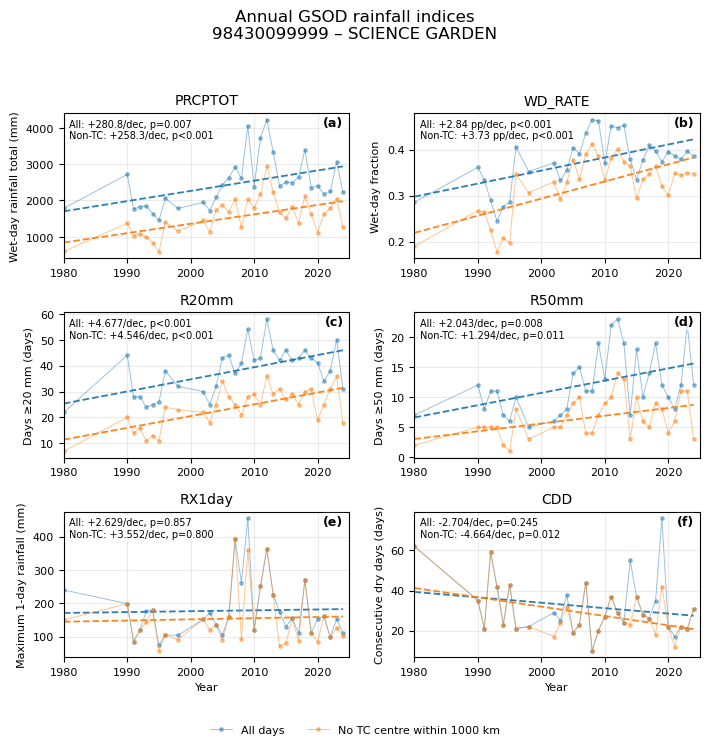

Saved: output/gsod_sanity_check/figures/composites/gsod_98430099999_annual_composite.png


In [34]:
station_id = "98430099999"
# station_id = "98429099999"

make_gsod_composite_timeseries_figure(
    data=gsod_all_period_indices,
    trend_summary=gsod_trend_summary,
    station_id=station_id,
    indices=GSOD_COMPOSITE_INDICES,
    period_type="Annual",
    period="Annual",
    output_path=GSOD_COMPOSITE_FIGURE_DIR / f"gsod_{station_id}_annual_composite.png",
    figure_title=f"Annual GSOD rainfall indices\n{station_label_from_id(station_id)}",
    ncols=2,
    panel_width=3.6,
    panel_height=2.45,
    annotate_stats=True,
)

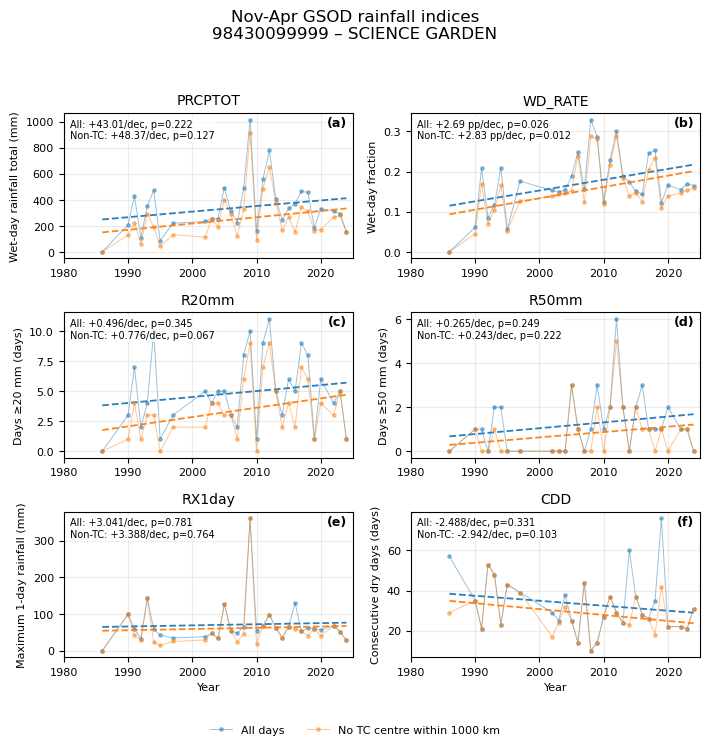

Saved: output/gsod_sanity_check/figures/composites/gsod_98430099999_nov_apr_composite.png


In [35]:
# station_id = "98429099999"

make_gsod_composite_timeseries_figure(
    data=gsod_all_period_indices,
    trend_summary=gsod_trend_summary,
    station_id=station_id,
    indices=GSOD_COMPOSITE_INDICES,
    period_type="Seasonal",
    period=DRY_SEASON_LABEL,
    output_path=GSOD_COMPOSITE_FIGURE_DIR / f"gsod_{station_id}_nov_apr_composite.png",
    figure_title=f"{DRY_SEASON_LABEL} GSOD rainfall indices\n{station_label_from_id(station_id)}",
    ncols=2,
    panel_width=3.6,
    panel_height=2.45,
    annotate_stats=True,
)

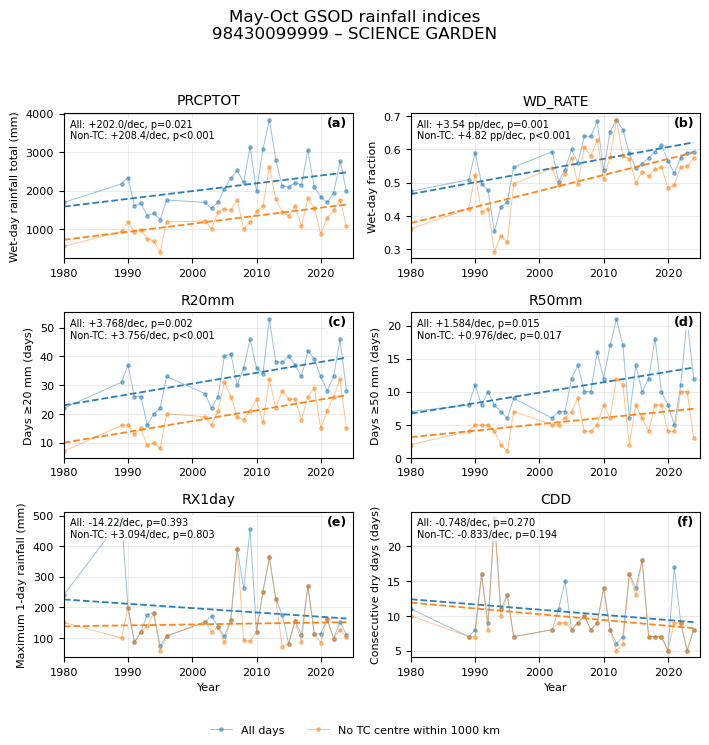

Saved: output/gsod_sanity_check/figures/composites/gsod_98430099999_may_oct_composite.png


In [36]:
# station_id = "98429099999"

make_gsod_composite_timeseries_figure(
    data=gsod_all_period_indices,
    trend_summary=gsod_trend_summary,
    station_id=station_id,
    indices=GSOD_COMPOSITE_INDICES,
    period_type="Seasonal",
    period=WET_SEASON_LABEL,
    output_path=GSOD_COMPOSITE_FIGURE_DIR / f"gsod_{station_id}_may_oct_composite.png",
    figure_title=f"{WET_SEASON_LABEL} GSOD rainfall indices\n{station_label_from_id(station_id)}",
    ncols=2,
    panel_width=3.6,
    panel_height=2.45,
    annotate_stats=True,
)